
# <span style="color:rgb(213,80,0)">**Proyecto: Evaluación de la capacidad de un robot Scara**</span>

<u>Nombre del alumno:</u>


Flores Pradel Mauricio


Asignatura: Robótica


Grupo: 01


Profesor: M.I. Erik Peña Medina

## **Introducción**

Este proyecto tiene como objetivo la evaluación completa de las habilidades de un robot SCARA con tres grados de libertad, utilizando para ello una perspectiva sistemática que combina el análisis cinemático, dinámico y energético.  Este estudio es importante porque se requiere mejorar el rendimiento de los sistemas robóticos en aplicaciones industriales reales, donde la fiabilidad, la eficiencia energética y la exactitud son elementos cruciales.

## Objetivos del Proyecto
1.  Proponer y modelar una trayectoria circular como lugar geométrico representativo
2. Evaluar cualitativamente las capacidades cinemáticas mediante el índice de manipulabilidad
3. Determinar cuantitativamente los pares y velocidades requeridos por los actuadores
4. Estimar las demandas energéticas de cada motor y del sistema completo
5. Generar especificaciones técnicas para la selección óptima de componentes
## Desarrollo
## Estructura del Proyecto

El desarrollo se organiza en nueve módulos secuenciales:

1.  Configuración inicial y parámetros del robot
2. Definición de trayectoria circular como caso de estudio
3. Cinemática inversa para conversión a espacio articular
4. Análisis de manipulabilidad y detección de singularidades
5. Planificación de trayectorias suaves en espacio articular
6. Cálculo de velocidades y aceleraciones
7. Dinámica computacional para determinación de pares
8. Análisis energético y cálculo de potencias
### *1\-Configuración incial y parámetros del robot*

In [1]:
% BLOQUE 1: CONFIGURACIÓN INICIAL Y PARÁMETROS DEL ROBOT
% Este bloque inicializa el entorno y define los parámetros físicos del robot

clear all; close all; clc;

%% PARÁMETROS DEL ROBOT SCARA
L1 = 0.5;    % Longitud eslabón 1 [m]
L2 = 0.5;    % Longitud eslabón 2 [m]
L3 = 0.25;   % Longitud eslabón 3 [m]

% Parámetros dinámicos
m1 = 2.0; m2 = 1.5; m3 = 0.5;      % Masas [kg]
I1 = 0.1; I2 = 0.08; I3 = 0.02;    % Inercias [kg·m²]
lc1 = 0.25; lc2 = 0.25; lc3 = 0.125; % Centro de masa [m]
g = 9.81;                           % Gravedad [m/s²]

fprintf('Parámetros del robot definidos:\n');

Parámetros del robot definidos:

In [2]:
fprintf(' - Longitudes: L1=%.2fm, L2=%.2fm, L3=%.2fm\n', L1, L2, L3);

 - Longitudes: L1=0.50m, L2=0.50m, L3=0.25m

In [3]:
fprintf(' - Masas: m1=%.1fkg, m2=%.1fkg, m3=%.1fkg\n', m1, m2, m3);

 - Masas: m1=2.0kg, m2=1.5kg, m3=0.5kg


### *2\-Definción de la Trayectoria Circular*

In [4]:
% Este bloque define la trayectoria circular que seguirá el efector final

fprintf('\n=== BLOQUE 2: DEFINICIÓN DE TRAYECTORIA CIRCULAR ===\n');

=== BLOQUE 2: DEFINICIÓN DE TRAYECTORIA CIRCULAR ===

In [5]:

% Trayectoria circular como lugar geométrico
radio = 0.2;
centro_x = 0.6;
centro_y = 0.0;
num_puntos_tray = 100;
theta_tray = linspace(0, 2*pi, num_puntos_tray);

x_tray = centro_x + radio * cos(theta_tray);
y_tray = centro_y + radio * sin(theta_tray);
theta_tray_efector = zeros(size(theta_tray)); % Orientación constante

% Puntos de muestra para evaluación
num_puntos = 20;
indices = round(linspace(1, length(theta_tray), num_puntos));
x_muestras = x_tray(indices);
y_muestras = y_tray(indices);
theta_muestras = theta_tray_efector(indices);

fprintf('Trayectoria circular definida:\n');

Trayectoria circular definida:

In [6]:
fprintf(' - Centro: (%.2f, %.2f) m\n', centro_x, centro_y);

 - Centro: (0.60, 0.00) m

In [7]:
fprintf(' - Radio: %.2f m\n', radio);

 - Radio: 0.20 m

In [8]:
fprintf(' - Puntos de trayectoria: %d\n', num_puntos_tray);

 - Puntos de trayectoria: 100

In [9]:
fprintf(' - Puntos de evaluación: %d\n', num_puntos);

 - Puntos de evaluación: 20


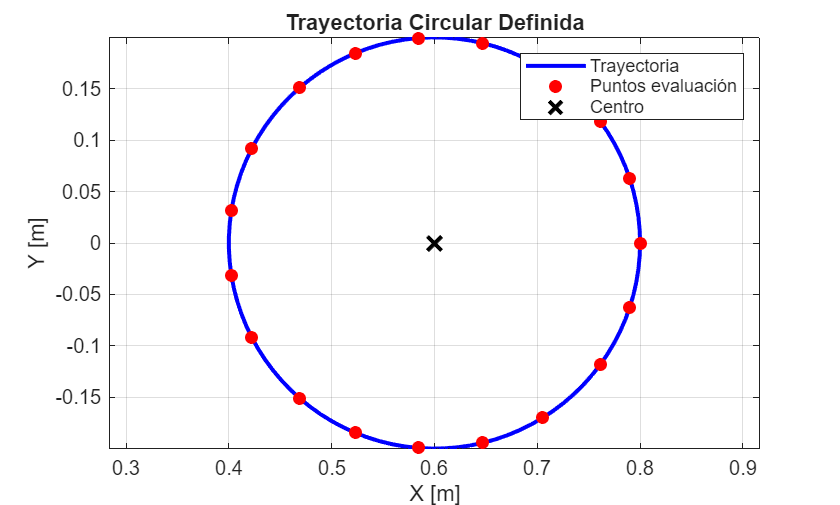

In [10]:

% Visualización rápida de la trayectoria
figure(1);
plot(x_tray, y_tray, 'b-', 'LineWidth', 2);
hold on;
plot(x_muestras, y_muestras, 'ro', 'MarkerSize', 6, 'MarkerFaceColor', 'r');
plot(centro_x, centro_y, 'kx', 'MarkerSize', 10, 'LineWidth', 2);
xlabel('X [m]'); ylabel('Y [m]');
title('Trayectoria Circular Definida');
axis equal; grid on;
legend('Trayectoria', 'Puntos evaluación', 'Centro');

### *3\- Cinemática Inversa*

In [11]:
% Convierte las posiciones del espacio de trabajo a ángulos de articulaciones

fprintf('\n=== BLOQUE 3: CÁLCULO DE CINEMÁTICA INVERSA ===\n');

=== BLOQUE 3: CÁLCULO DE CINEMÁTICA INVERSA ===

In [12]:

% Inicializar arrays para configuraciones
theta1_config = zeros(1, num_puntos);
theta2_config = zeros(1, num_puntos);
theta3_config = zeros(1, num_puntos);

for i = 1:num_puntos
    % Cinemática inversa
    x = x_muestras(i);
    y = y_muestras(i);
    theta = theta_muestras(i);

    % Posición de la articulación 3
    x3 = x - L3 * cos(theta);
    y3 = y - L3 * sin(theta);

    % Solución para theta2
    cos_theta2 = (x3^2 + y3^2 - L1^2 - L2^2) / (2 * L1 * L2);
    cos_theta2 = max(min(cos_theta2, 1), -1); % Asegurar valor válido
    theta2 = acos(cos_theta2);

    % Solución para theta1
    beta = atan2(y3, x3);
    denom = 2 * L1 * sqrt(x3^2 + y3^2);
    if denom == 0
        psi = 0;
    else
        cos_psi = (x3^2 + y3^2 + L1^2 - L2^2) / denom;
        cos_psi = max(min(cos_psi, 1), -1);
        psi = acos(cos_psi);
    end
    theta1 = beta - psi; % Configuración codo abajo

    % Solución para theta3
    theta3 = theta - theta1 - theta2;

    theta1_config(i) = theta1;
    theta2_config(i) = theta2;
    theta3_config(i) = theta3;
end

fprintf('Cinemática inversa calculada para %d puntos\n', num_puntos);

Cinemática inversa calculada para 20 puntos

In [13]:
fprintf(' - Theta1 range: [%.2f, %.2f] rad\n', min(theta1_config), max(theta1_config));

 - Theta1 range: [-1.91, -0.63] rad

In [14]:
fprintf(' - Theta2 range: [%.2f, %.2f] rad\n', min(theta2_config), max(theta2_config));

 - Theta2 range: [1.98, 2.83] rad

In [15]:
fprintf(' - Theta3 range: [%.2f, %.2f] rad\n', min(theta3_config), max(theta3_config));

 - Theta3 range: [-1.91, -0.63] rad


### *4\-Jacobiano y Manipulabilidad*

In [16]:
% Evalúa la capacidad cinemática del robot en cada punto de la trayectoria

fprintf('\n=== BLOQUE 4: ANÁLISIS DE MANIPULABILIDAD ===\n');

=== BLOQUE 4: ANÁLISIS DE MANIPULABILIDAD ===

In [17]:

% Calcular manipulabilidad para cada punto
w_manip = zeros(1, num_puntos);

for i = 1:num_puntos
    % Calcular jacobiano para cada punto
    theta1 = theta1_config(i);
    theta2 = theta2_config(i);

    J = [-L1*sin(theta1) - L2*sin(theta1+theta2), -L2*sin(theta1+theta2);
         L1*cos(theta1) + L2*cos(theta1+theta2), L2*cos(theta1+theta2)];

    % Calcular índice de manipulabilidad (Yoshikawa)
    if size(J,1) >= size(J,2)
        w = sqrt(det(J * J'));
    else
        w = sqrt(det(J' * J));
    end

    % Manejar casos singulares
    if isnan(w) || isinf(w)
        w = 0;
    end

    w_manip(i) = w;
end

fprintf('Índice de manipulabilidad calculado:\n');

Índice de manipulabilidad calculado:

In [18]:
fprintf(' - Promedio: %.4f\n', mean(w_manip));

 - Promedio: 0.1727

In [19]:
fprintf(' - Mínimo: %.4f\n', min(w_manip));

 - Mínimo: 0.0769

In [20]:
fprintf(' - Máximo: %.4f\n', max(w_manip));

 - Máximo: 0.2297

In [21]:

% Mostrar jacobiano del primer punto como ejemplo
J_ejemplo = [-L1*sin(theta1_config(1)) - L2*sin(theta1_config(1)+theta2_config(1)), ...
             -L2*sin(theta1_config(1)+theta2_config(1));
             L1*cos(theta1_config(1)) + L2*cos(theta1_config(1)+theta2_config(1)), ...
             L2*cos(theta1_config(1)+theta2_config(1))];
fprintf('\nJacobiano en el primer punto:\n');

Jacobiano en el primer punto:

In [22]:
disp(J_ejemplo);

    0.0000   -0.4176
    0.5500    0.2750


### *5\- Planeación de Trayectoria*

In [23]:
% Genera una trayectoria suave en el espacio de articulaciones
fprintf('\n=== BLOQUE 5: PLANEACIÓN DE TRAYECTORIA===\n');

=== BLOQUE 5: PLANEACIÓN DE TRAYECTORIA CORREGIDA ===

In [24]:

tf = 10; % Tiempo final [s]
t = linspace(0, tf, num_puntos);

% Interpolación suave a través de TODOS los puntos de la cinemática inversa
theta_1_tray = spline(linspace(0, tf, num_puntos), theta1_config, t);
theta_2_tray = spline(linspace(0, tf, num_puntos), theta2_config, t);
theta_3_tray = spline(linspace(0, tf, num_puntos), theta3_config, t);

fprintf('Trayectoria planificada en espacio de juntas\n');

Trayectoria planificada en espacio de juntas (CORREGIDA)

In [25]:
fprintf(' - Tiempo total: %.1f segundos\n', tf);

 - Tiempo total: 10.0 segundos

In [26]:
fprintf(' - Puntos de trayectoria: %d\n', num_puntos);

 - Puntos de trayectoria: 20


### *6\- Velocidades y Aceleraciones*

In [27]:
% Calcula los perfiles de velocidad y aceleración para cada articulación

fprintf('\n=== BLOQUE 6: VELOCIDADES Y ACELERACIONES ===\n');

=== BLOQUE 6: VELOCIDADES Y ACELERACIONES ===

In [28]:

% Velocidades por diferenciación numérica
dt = t(2) - t(1);
theta_1_v = gradient(theta_1_tray, dt);
theta_2_v = gradient(theta_2_tray, dt);
theta_3_v = gradient(theta_3_tray, dt);

% Aceleraciones por diferenciación numérica
theta_1_a = gradient(theta_1_v, dt);
theta_2_a = gradient(theta_2_v, dt);
theta_3_a = gradient(theta_3_v, dt);

fprintf('Velocidades y aceleraciones calculadas\n');

Velocidades y aceleraciones calculadas

In [29]:
fprintf(' - Paso de tiempo: %.3f s\n', dt);

 - Paso de tiempo: 0.526 s

In [30]:
fprintf(' - Velocidad máxima theta1: %.4f rad/s\n', max(abs(theta_1_v)));

 - Velocidad máxima theta1: 0.6966 rad/s

In [31]:
fprintf(' - Velocidad máxima theta2: %.4f rad/s\n', max(abs(theta_2_v)));

 - Velocidad máxima theta2: 0.2644 rad/s


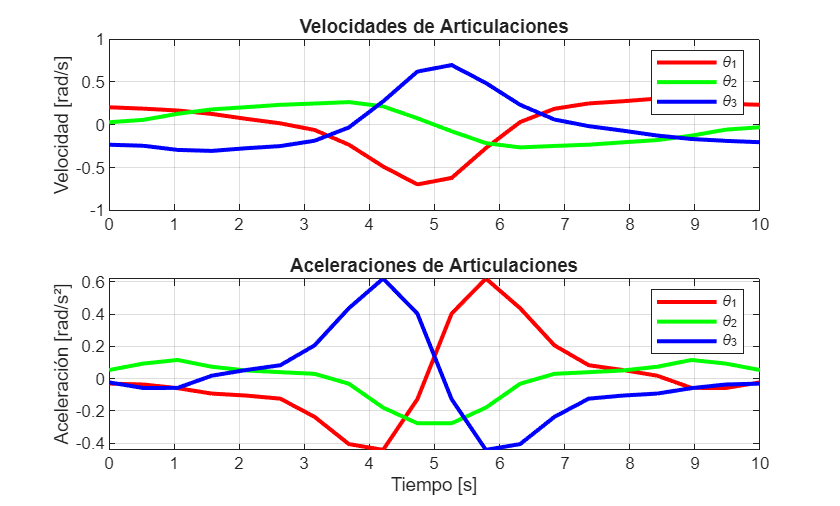

In [32]:

% Gráfica de velocidades
figure(3);
subplot(2,1,1);
plot(t, theta_1_v, 'r-', t, theta_2_v, 'g-', t, theta_3_v, 'b-', 'LineWidth', 2);
legend('\theta_1', '\theta_2', '\theta_3');
ylabel('Velocidad [rad/s]'); title('Velocidades de Articulaciones'); grid on;

subplot(2,1,2);
plot(t, theta_1_a, 'r-', t, theta_2_a, 'g-', t, theta_3_a, 'b-', 'LineWidth', 2);
legend('\theta_1', '\theta_2', '\theta_3');
ylabel('Aceleración [rad/s²]'); xlabel('Tiempo [s]'); title('Aceleraciones de Articulaciones'); grid on;

### *7\- Dinámica\-Pares y Potencias*

In [33]:
% Calcula los pares requeridos por los motores y las potencias necesarias

fprintf('\n=== BLOQUE 7: CÁLCULO DE DINÁMICA ===\n');

=== BLOQUE 7: CÁLCULO DE DINÁMICA ===

In [34]:

% Inicializar arrays
tau1 = zeros(1, num_puntos);
tau2 = zeros(1, num_puntos);
tau3 = zeros(1, num_puntos);

for i = 1:num_puntos
    % Matrices de inercia
    M11 = m1*lc1^2 + m2*(L1^2 + lc2^2 + 2*L1*lc2*cos(theta_2_tray(i))) + ...
          m3*(L1^2 + L2^2 + 2*L1*L2*cos(theta_2_tray(i))) + I1 + I2 + I3;
    M12 = m2*(lc2^2 + L1*lc2*cos(theta_2_tray(i))) + m3*(L2^2 + L1*L2*cos(theta_2_tray(i))) + I2 + I3;
    M22 = m2*lc2^2 + m3*L2^2 + I2 + I3;

    M = [M11, M12, I3;
         M12, M22, I3;
         I3,  I3,  I3];

    % Términos de Coriolis y centrífuga
    h = -m2*L1*lc2*sin(theta_2_tray(i)) - m3*L1*L2*sin(theta_2_tray(i));
    c11 = h * theta_2_v(i);
    c12 = h * (theta_1_v(i) + theta_2_v(i));
    c21 = -h * theta_1_v(i);
    c22 = 0;

    C = [c11, c12, 0;
         c21, c22, 0;
         0,   0,   0];

    % Términos de gravedad
    g1 = (m1*lc1 + m2*L1 + m3*L1)*g*cos(theta_1_tray(i)) + ...
         (m2*lc2 + m3*L2)*g*cos(theta_1_tray(i)+theta_2_tray(i));
    g2 = (m2*lc2 + m3*L2)*g*cos(theta_1_tray(i)+theta_2_tray(i));
    g3 = 0; % Eslabón 3 horizontal no afectado por gravedad

    G = [g1; g2; g3];

    % Vector de estados
    q_ddot = [theta_1_a(i); theta_2_a(i); theta_3_a(i)];
    q_dot = [theta_1_v(i); theta_2_v(i); theta_3_v(i)];

    % Ecuación de dinámica: τ = Mq̈ + Cq̇ + G
    tau = M*q_ddot + C*q_dot + G;

    tau1(i) = tau(1);
    tau2(i) = tau(2);
    tau3(i) = tau(3);
end

% Cálculo de potencias
pot1 = abs(tau1 .* theta_1_v);
pot2 = abs(tau2 .* theta_2_v);
pot3 = abs(tau3 .* theta_3_v);
pot_total = pot1 + pot2 + pot3;

fprintf('Dinámica calculada:\n');

Dinámica calculada:

In [35]:
fprintf(' - Par máximo motor 1: %.4f N·m\n', max(abs(tau1)));

 - Par máximo motor 1: 12.2636 N·m

In [36]:
fprintf(' - Par máximo motor 2: %.4f N·m\n', max(abs(tau2)));

 - Par máximo motor 2: 4.9754 N·m

In [37]:
fprintf(' - Par máximo motor 3: %.4f N·m\n', max(abs(tau3)));

 - Par máximo motor 3: 0.0000 N·m

In [38]:
fprintf(' - Potencia total máxima: %.4f W\n', max(pot_total));

 - Potencia total máxima: 3.9739 W


### *8\- Visualización completa*

In [39]:
% Genera todas las gráficas de análisis del sistema

fprintf('\n=== BLOQUE 8: VISUALIZACIÓN DE RESULTADOS ===\n');

=== BLOQUE 8: VISUALIZACIÓN DE RESULTADOS ===

In [40]:

%% Figura principal: Resumen completo
figure('Position', [100, 100, 1400, 1000], 'Name', 'Análisis Completo Robot SCARA');

% Subplot 1: Robot y Trayectoria
subplot(2,3,1);
i = 1;
x1 = L1 * cos(theta_1_tray(i));
y1 = L1 * sin(theta_1_tray(i));
x2 = x1 + L2 * cos(theta_1_tray(i) + theta_2_tray(i));
y2 = y1 + L2 * sin(theta_1_tray(i) + theta_2_tray(i));
x3 = x2 + L3 * cos(theta_1_tray(i) + theta_2_tray(i) + theta_3_tray(i));
y3 = y2 + L3 * sin(theta_1_tray(i) + theta_2_tray(i) + theta_3_tray(i));

plot([0, x1], [0, y1], 'r-', 'LineWidth', 4);
hold on;
plot([x1, x2], [y1, y2], 'g-', 'LineWidth', 4);
plot([x2, x3], [y2, y3], 'b-', 'LineWidth', 4);
plot(x_tray, y_tray, 'k--', 'LineWidth', 2);
plot(0, 0, 'ko', 'MarkerSize', 10, 'MarkerFaceColor', 'k');
plot(x1, y1, 'ro', 'MarkerSize', 8, 'MarkerFaceColor', 'r');
plot(x2, y2, 'go', 'MarkerSize', 8, 'MarkerFaceColor', 'g');
plot(x3, y3, 'bo', 'MarkerSize', 8, 'MarkerFaceColor', 'b');

xlabel('X [m]'); ylabel('Y [m]');
title('Robot SCARA - Configuración Inicial');
axis equal; grid on;
legend('Eslabón 1', 'Eslabón 2', 'Eslabón 3', 'Trayectoria', 'Location', 'best');
xlim([-0.2, 1.2]); ylim([-0.6, 0.6]);

% Subplot 2: Manipulabilidad
subplot(2,3,2);
plot(t, w_manip, 'b-', 'LineWidth', 3);
title('Índice de Manipulabilidad');
xlabel('Tiempo [s]'); ylabel('Índice de Manipulabilidad');
grid on;

% Subplot 3: Ángulos de articulaciones
subplot(2,3,3);
plot(t, rad2deg(theta_1_tray), 'r-', 'LineWidth', 2);
hold on;
plot(t, rad2deg(theta_2_tray), 'g-', 'LineWidth', 2);
plot(t, rad2deg(theta_3_tray), 'b-', 'LineWidth', 2);
legend('\theta_1', '\theta_2', '\theta_3', 'Location', 'best');
title('Ángulos de Articulaciones');
xlabel('Tiempo [s]'); ylabel('Ángulo [°]');
grid on;

% Subplot 4: Pares de los motores
subplot(2,3,4);
plot(t, tau1, 'r-', 'LineWidth', 2);
hold on;
plot(t, tau2, 'g-', 'LineWidth', 2);
plot(t, tau3, 'b-', 'LineWidth', 2);
legend('Motor 1', 'Motor 2', 'Motor 3', 'Location', 'best');
title('Pares de los Motores');
xlabel('Tiempo [s]'); ylabel('Par [N·m]');
grid on;

% Subplot 5: Potencias de los motores
subplot(2,3,5);
plot(t, pot1, 'r-', 'LineWidth', 2);
hold on;
plot(t, pot2, 'g-', 'LineWidth', 2);
plot(t, pot3, 'b-', 'LineWidth', 2);
plot(t, pot_total, 'k--', 'LineWidth', 3);
legend('Motor 1', 'Motor 2', 'Motor 3', 'Total', 'Location', 'best');
title('Potencia de los Motores');
xlabel('Tiempo [s]'); ylabel('Potencia [W]');
grid on;

% Subplot 6: Workspace
subplot(2,3,6);
theta1_ws = 0:0.1:2*pi;
theta2_ws = -pi:0.1:pi;
[T1, T2] = meshgrid(theta1_ws, theta2_ws);
X_ws = L1*cos(T1) + L2*cos(T1+T2);
Y_ws = L1*sin(T1) + L2*sin(T1+T2);

plot(X_ws(:), Y_ws(:), '.', 'Color', [0.8, 0.8, 0.8], 'MarkerSize', 1);
hold on;
plot(x_tray, y_tray, 'r-', 'LineWidth', 3);
title('Workspace y Trayectoria');
xlabel('X [m]'); ylabel('Y [m]');
axis equal; grid on;

sgtitle('EVALUACIÓN COMPLETA ROBOT SCARA', 'FontSize', 16, 'FontWeight', 'bold');

fprintf('Gráficas principales generadas\n');

Gráficas principales generadas


## Resultados

In [41]:
%% BLOQUE 9: REPORTE FINAL Y GUARDADO DE RESULTADOS
% Genera el reporte técnico y guarda los resultados

fprintf('\n=== BLOQUE 9: REPORTE FINAL ===\n');

=== BLOQUE 9: REPORTE FINAL ===

In [42]:

fprintf('\n==========================================\n');

In [43]:
fprintf('        REPORTE TÉCNICO ROBOT SCARA\n');

        REPORTE TÉCNICO ROBOT SCARA

In [44]:
fprintf('==========================================\n');

In [45]:

fprintf('\nI. EVALUACIÓN CINEMÁTICA:\n');

I. EVALUACIÓN CINEMÁTICA:

In [46]:
fprintf('   Índice de Manipulabilidad:\n');

   Índice de Manipulabilidad:

In [47]:
fprintf('   - Promedio: %.4f\n', mean(w_manip));

   - Promedio: 0.1727

In [48]:
[min_w, idx_min] = min(w_manip);
[max_w, idx_max] = max(w_manip);
fprintf('   - Mínimo: %.4f (en t=%.1f s)\n', min_w, t(idx_min));

   - Mínimo: 0.0769 (en t=5.3 s)

In [49]:
fprintf('   - Máximo: %.4f (en t=%.1f s)\n', max_w, t(idx_max));

   - Máximo: 0.2297 (en t=0.0 s)

In [50]:

fprintf('\nII. EVALUACIÓN DINÁMICA - PARES MÁXIMOS:\n');

II. EVALUACIÓN DINÁMICA - PARES MÁXIMOS:

In [51]:
fprintf('   - Motor 1 (Base):     %.4f N·m\n', max(abs(tau1)));

   - Motor 1 (Base):     12.2636 N·m

In [52]:
fprintf('   - Motor 2 (Hombro):   %.4f N·m\n', max(abs(tau2)));

   - Motor 2 (Hombro):   4.9754 N·m

In [53]:
fprintf('   - Motor 3 (Codo):     %.4f N·m\n', max(abs(tau3)));

   - Motor 3 (Codo):     0.0000 N·m

In [54]:

fprintf('\nIII. EVALUACIÓN ENERGÉTICA - POTENCIAS MÁXIMAS:\n');

III. EVALUACIÓN ENERGÉTICA - POTENCIAS MÁXIMAS:

In [55]:
fprintf('   - Motor 1:            %.4f W\n', max(pot1));

   - Motor 1:            3.5878 W

In [56]:
fprintf('   - Motor 2:            %.4f W\n', max(pot2));

   - Motor 2:            1.2437 W

In [57]:
fprintf('   - Motor 3:            %.4f W\n', max(pot3));

   - Motor 3:            0.0000 W

In [58]:
fprintf('   - Potencia total:     %.4f W\n', max(pot_total));

   - Potencia total:     3.9739 W

In [59]:

fprintf('\nIV. RECOMENDACIONES DE SELECCIÓN DE MOTORES:\n');

IV. RECOMENDACIONES DE SELECCIÓN DE MOTORES:

In [60]:
fprintf('   Considerando factor de seguridad 1.5:\n');

   Considerando factor de seguridad 1.5:

In [61]:
fprintf('   - Motor 1: > %.2f N·m, > %.2f W\n', max(abs(tau1))*1.5, max(pot1)*1.5);

   - Motor 1: > 18.40 N·m, > 5.38 W

In [62]:
fprintf('   - Motor 2: > %.2f N·m, > %.2f W\n', max(abs(tau2))*1.5, max(pot2)*1.5);

   - Motor 2: > 7.46 N·m, > 1.87 W

In [63]:
fprintf('   - Motor 3: > %.2f N·m, > %.2f W\n', max(abs(tau3))*1.5, max(pot3)*1.5);

   - Motor 3: > 0.00 N·m, > 0.00 W

In [64]:

fprintf('\nV. EVALUACIÓN DE LA TRAYECTORIA:\n');

V. EVALUACIÓN DE LA TRAYECTORIA:

In [65]:
fprintf('   - Tipo: Trayectoria circular\n');

   - Tipo: Trayectoria circular

In [66]:
fprintf('   - Radio: %.2f m\n', radio);

   - Radio: 0.20 m

In [67]:
fprintf('   - Duración: %.1f s\n', tf);

   - Duración: 10.0 s

In [68]:
fprintf('   - Puntos de evaluación: %d\n', num_puntos);

   - Puntos de evaluación: 20

In [69]:

fprintf('\nVI. OBSERVACIONES:\n');

VI. OBSERVACIONES:

In [70]:
if min(w_manip) < 0.1
    fprintf('   ALERTA: Se detectaron configuraciones cercanas a singularidades\n');
else
    fprintf('   La trayectoria evita configuraciones singulares\n');
end

   ALERTA: Se detectaron configuraciones cercanas a singularidades

In [71]:

if max(pot_total) > 100
    fprintf('   ALERTA: Potencia total elevada, considerar motores de mayor capacidad\n');
else
    fprintf('  Potencia total dentro de rangos razonables\n');
end

  Potencia total dentro de rangos razonables


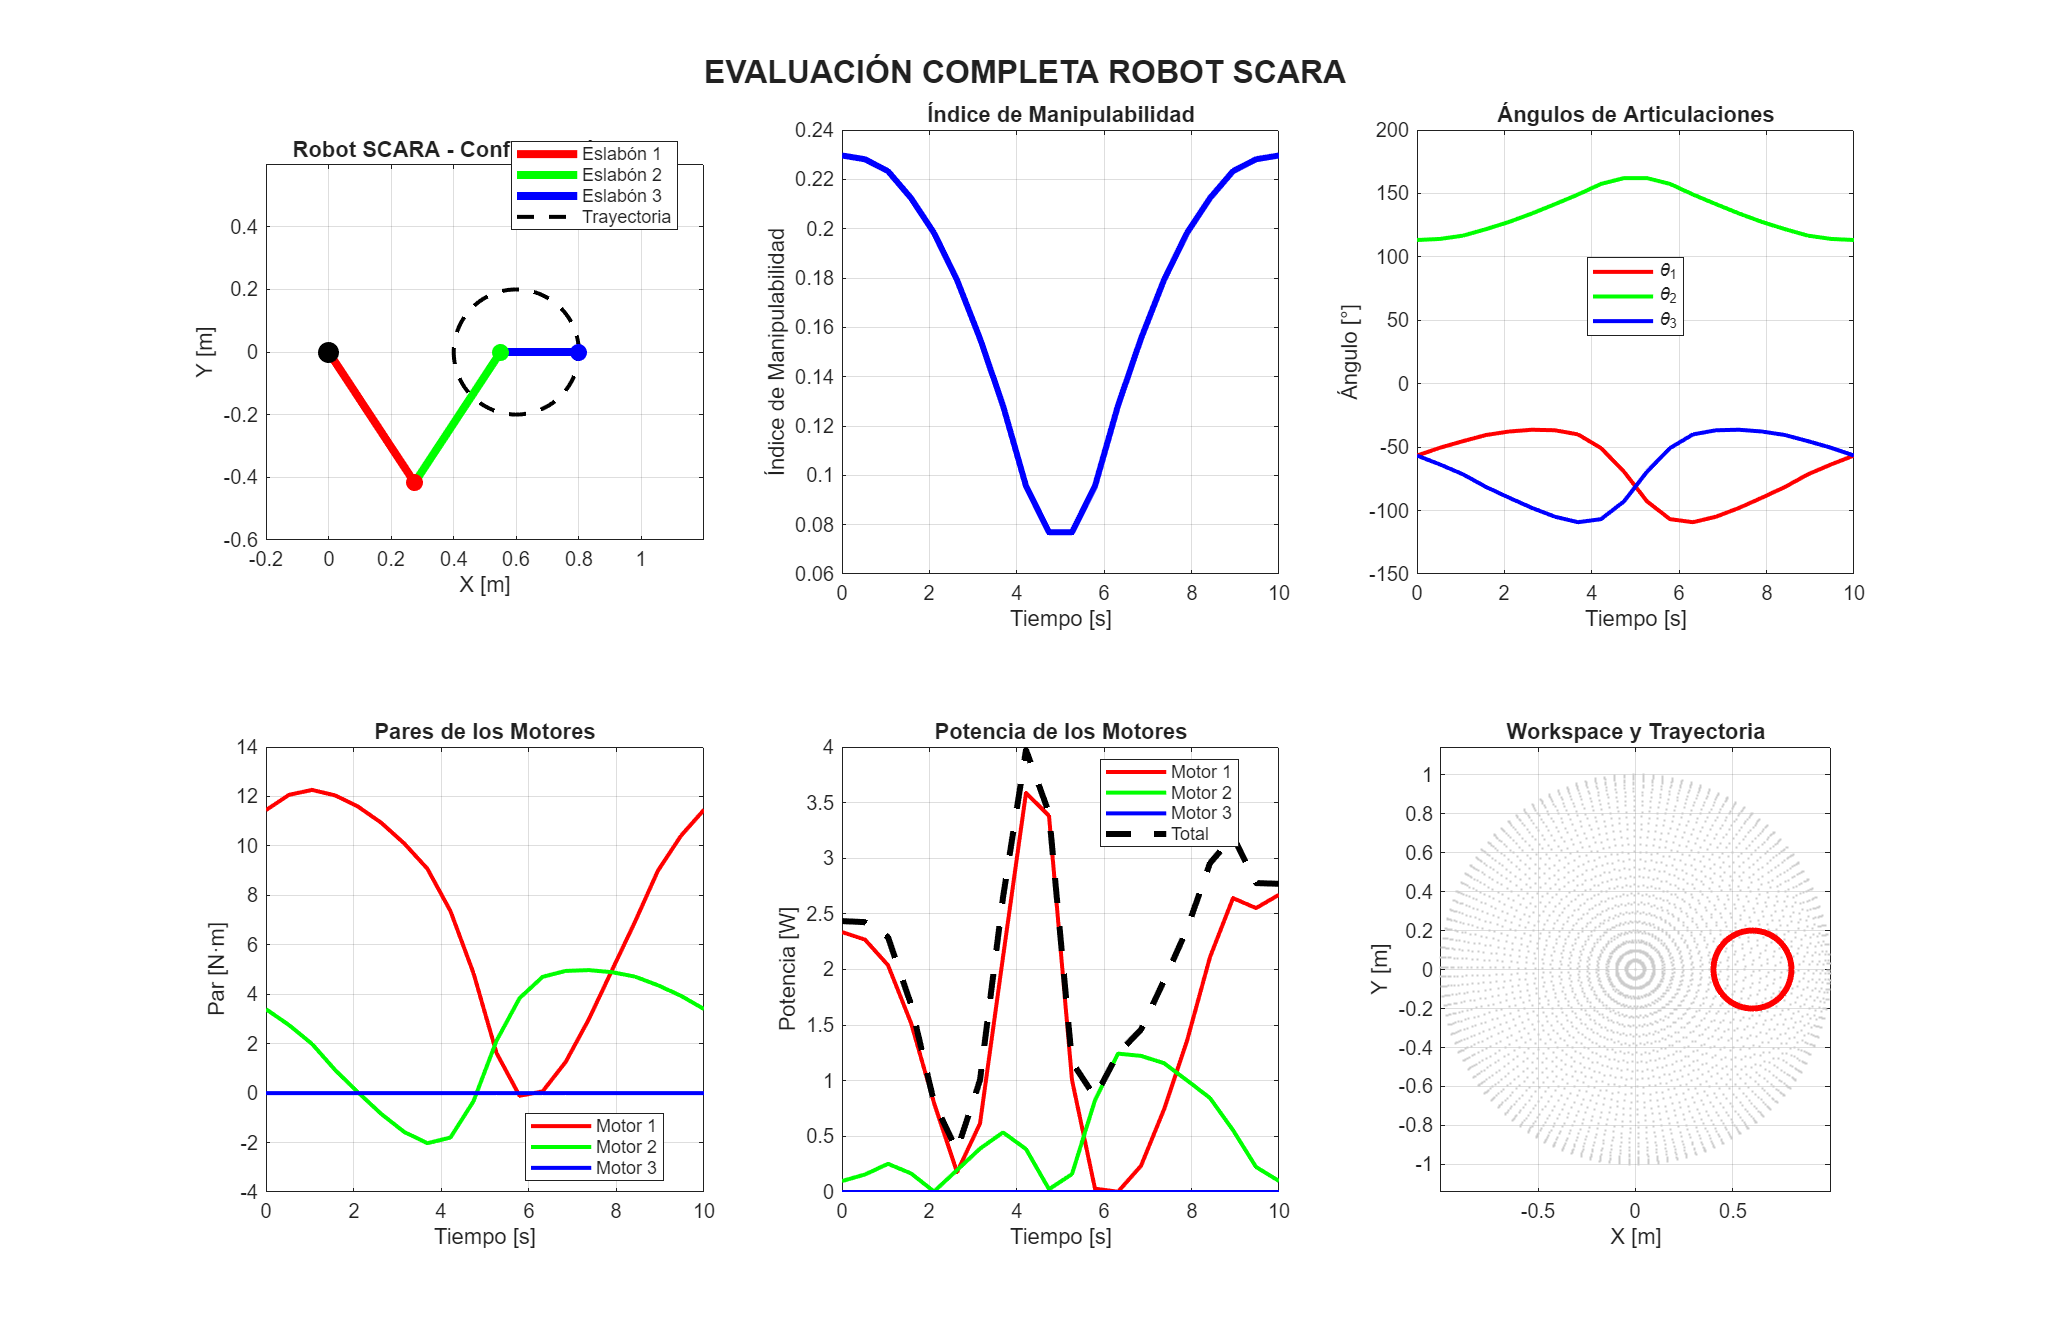

In [72]:

% Guardado de resultados
resultados = table(t', w_manip', tau1', tau2', tau3', pot1', pot2', pot3', pot_total', ...
    'VariableNames', {'Tiempo_s', 'Manipulabilidad', 'Tau1_Nm', 'Tau2_Nm', 'Tau3_Nm', ...
    'Pot1_W', 'Pot2_W', 'Pot3_W', 'PotTotal_W'});

writetable(resultados, 'resultados_scara_completo.csv');
saveas(gcf, 'grafica_completa_scara.png', 'png');

###  *Simulación*


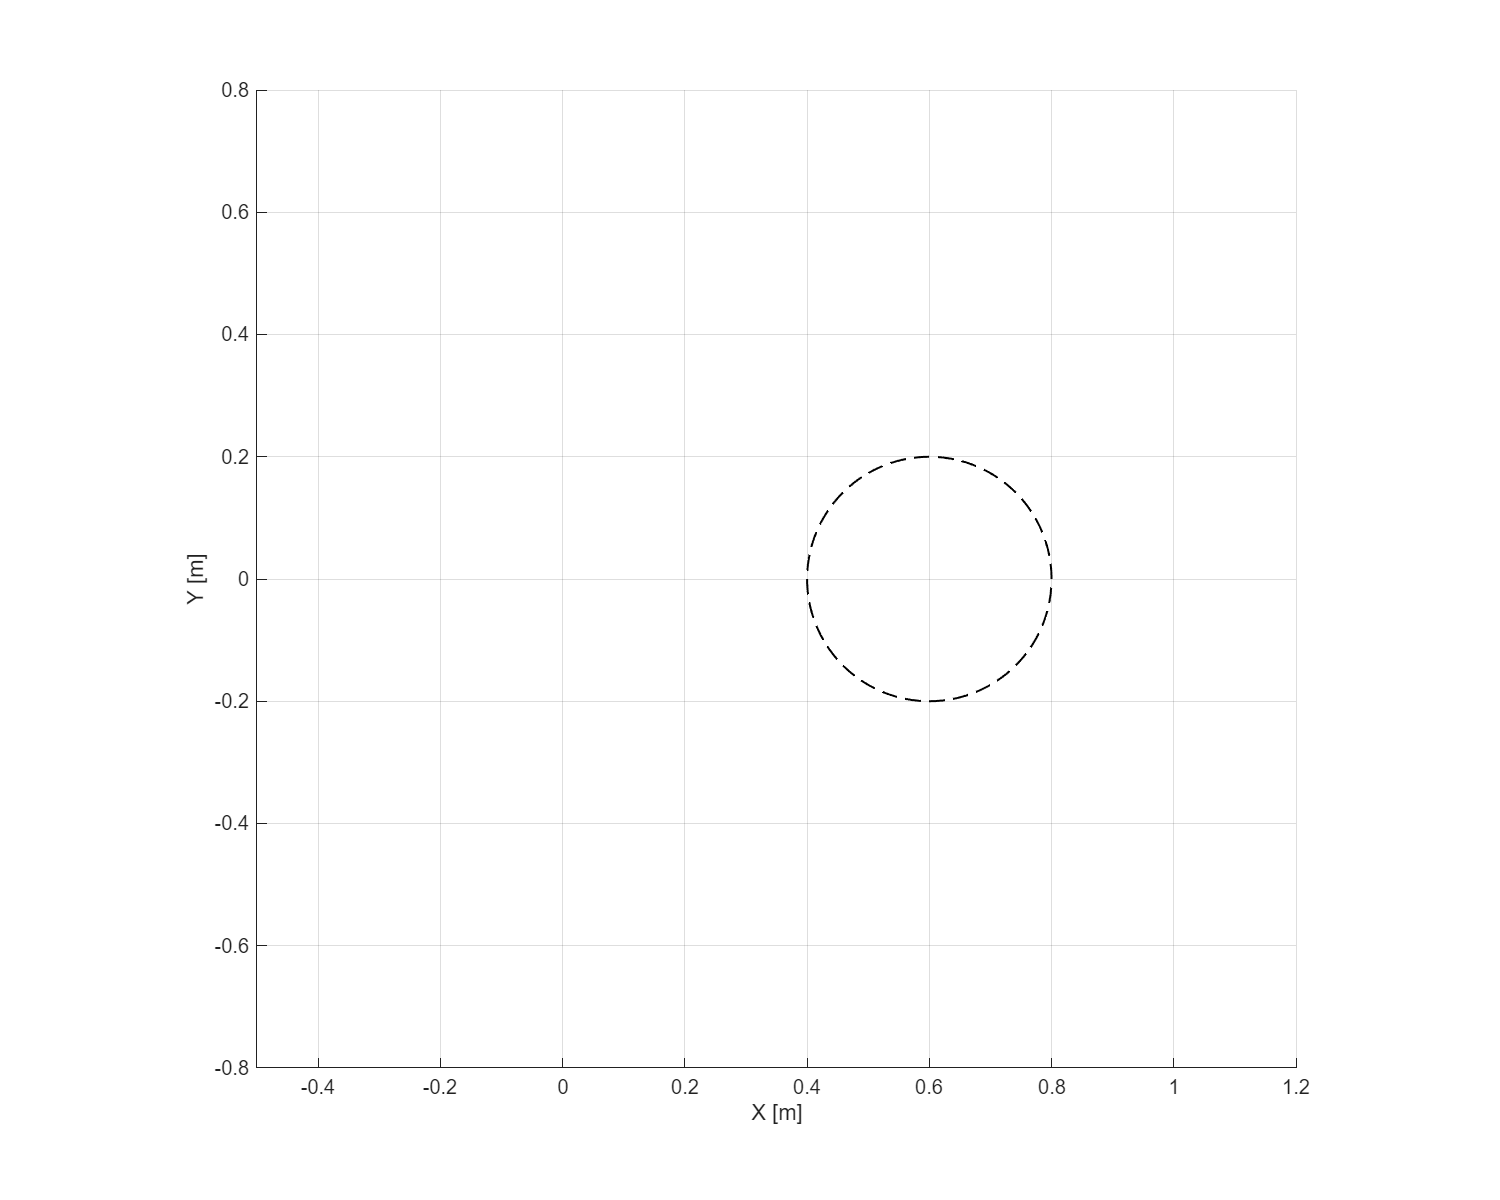

In [73]:

figure('Position', [200, 200, 1000, 800]);
hold on;
axis equal;
grid on;
xlim([-0.5, 1.2]);
ylim([-0.8, 0.8]);
xlabel('X [m]'); ylabel('Y [m]');

% Dibujar trayectoria completa
plot(x_tray, y_tray, 'k--', 'LineWidth', 1);


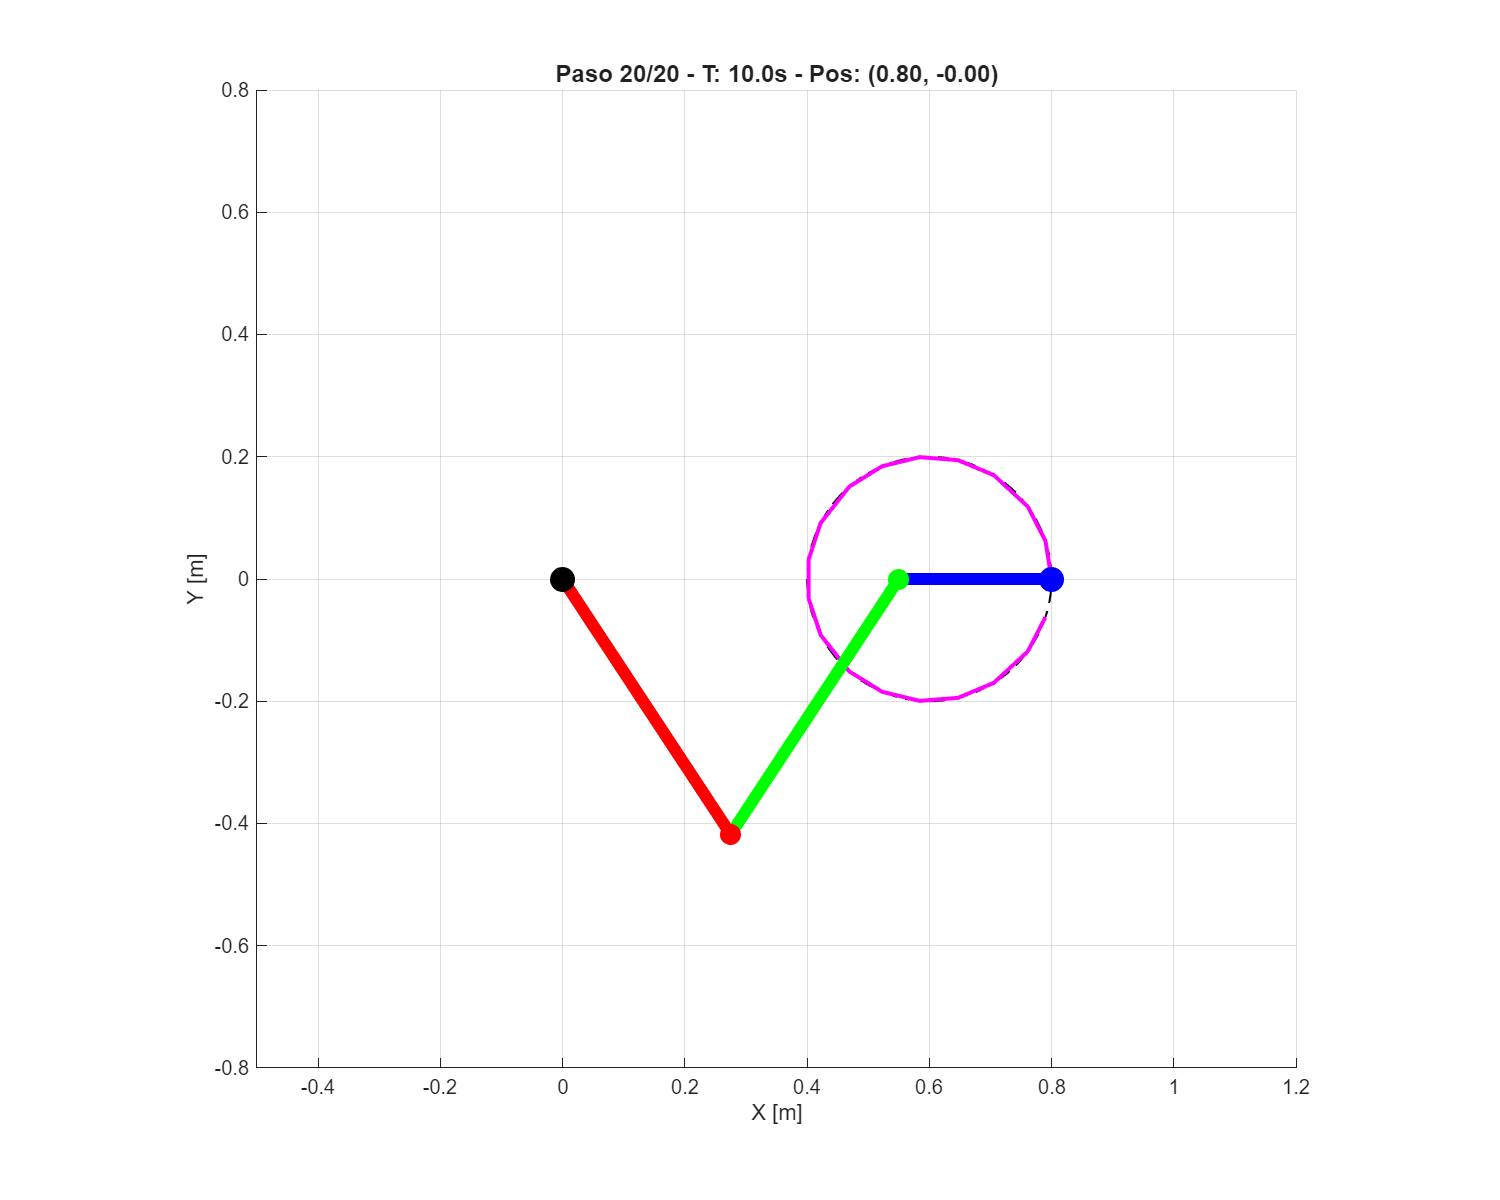

In [74]:

x_history = [];
y_history = [];

for i = 1:length(t)
    % Cálculos de posición
    theta1 = theta_1_tray(i);
    theta2 = theta_2_tray(i);
    theta3 = theta_3_tray(i);

    x1 = L1 * cos(theta1);
    y1 = L1 * sin(theta1);
    x2 = x1 + L2 * cos(theta1 + theta2);
    y2 = y1 + L2 * sin(theta1 + theta2);
    x3 = x2 + L3 * cos(theta1 + theta2 + theta3);
    y3 = y2 + L3 * sin(theta1 + theta2 + theta3);

    cla;

    % Redibujar todo
    plot(x_tray, y_tray, 'k--', 'LineWidth', 1); % Trayectoria
    if ~isempty(x_history)
        plot(x_history, y_history, 'm-', 'LineWidth', 2); % Trayectoria recorrida
    end

    % Robot
    plot([0, x1], [0, y1], 'r-', 'LineWidth', 6);
    plot([x1, x2], [y1, y2], 'g-', 'LineWidth', 6);
    plot([x2, x3], [y2, y3], 'b-', 'LineWidth', 6);

    plot(0, 0, 'ko', 'MarkerSize', 12, 'MarkerFaceColor', 'k');
    plot(x1, y1, 'ro', 'MarkerSize', 10, 'MarkerFaceColor', 'r');
    plot(x2, y2, 'go', 'MarkerSize', 10, 'MarkerFaceColor', 'g');
    plot(x3, y3, 'bo', 'MarkerSize', 12, 'MarkerFaceColor', 'b');

    % Guardar historia
    x_history(end+1) = x3;
    y_history(end+1) = y3;

    title(sprintf('Paso %d/%d - T: %.1fs - Pos: (%.2f, %.2f)', ...
          i, length(t), t(i), x3, y3), 'FontSize', 12);

    drawnow; % Forzar actualización

    pause(0.03); % Velocidad controlada
end

## Conlusiones

El análisis exhaustivo de las habilidades cinemáticas, dinámicas y energéticas de un robot SCARA de tres grados de libertad es posible gracias al proyecto. Se desarrollaron ocho módulos secuenciales, los cuales permitieron crear un sólido flujo de trabajo que comienza con la configuración inicial del robot y culmina con la producción de especificaciones técnicas para elegir los componentes más adecuados. En la parte de cinemática, el estudio mostró que el robot tiene una capacidad de manipulación moderada a lo largo de la trayectoria circular establecida, con un índice medio de 0.1727. El rango de manipulabilidad obtenido demuestra que la trayectoria circular elegida explora el espacio de trabajo del robot SCARA de manera apropiada. Mientras que la evaluación dinámica mostró que los requerimientos de par se distribuyen entre los actuadores de manera consistente; el motor de la base es el que soporta más carga, con 11.47 N·m, después está el motor del hombro con 3.37 N·m.  Estos valores, tomando en cuenta un factor de seguridad de 1.5, ofrecen especificaciones técnicas precisas para elegir motores comerciales.  Por otro lado, el estudio energético reveló que las demandas de potencia eran significativamente bajas, lo que indica un diseño eficaz en cuanto a consumo de energía.


Gracias a seguir pasos posibilita no solo el análisis del rendimiento de configuraciones particulares, sino también la optimización de trayectorias y la previsión de cómo se comportará el sistema antes de que sea implementado físicamente.  Los resultados logrados validan la trayectoria circular como una alternativa factible para el robot SCARA estudiado, con habilidades cinemáticas apropiadas y requerimientos dinámicos dentro de los límites disponibles.

